In [63]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [64]:
btc = yf.download("BTC-USD", start="2023-01-01")
btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566


In [65]:
btc.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1231 entries, 2023-01-01 to 2026-05-16
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   1231 non-null   float64
 1   (High, BTC-USD)    1231 non-null   float64
 2   (Low, BTC-USD)     1231 non-null   float64
 3   (Open, BTC-USD)    1231 non-null   float64
 4   (Volume, BTC-USD)  1231 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 57.7 KB


In [66]:
btc.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,1231.000000,1231.000000,1231.000000,1231.000000,1.231000e+03
mean,66673.800043,67778.745037,65446.312122,66621.224011,3.674915e+10
std,30357.868100,30815.093573,29877.773899,30388.643378,2.338400e+10
min,16625.080078,16630.439453,16521.234375,16547.914062,5.331173e+09
25%,35065.775391,35434.134766,34570.029297,35046.291016,1.882912e+10
50%,67195.867188,68365.781250,65842.296875,67164.914062,3.175303e+10
75%,93529.015625,94953.777344,91344.437500,93490.726562,4.796710e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,1.817464e+11


In [67]:
btc.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [68]:
btc["Close"]

Ticker,BTC-USD
Date,
2023-01-01,16625.080078
2023-01-02,16688.470703
2023-01-03,16679.857422
2023-01-04,16863.238281
2023-01-05,16836.736328
...,...
2026-05-11,81728.296875
2026-05-12,80477.492188
2026-05-13,79277.117188


<Axes: xlabel='Date'>

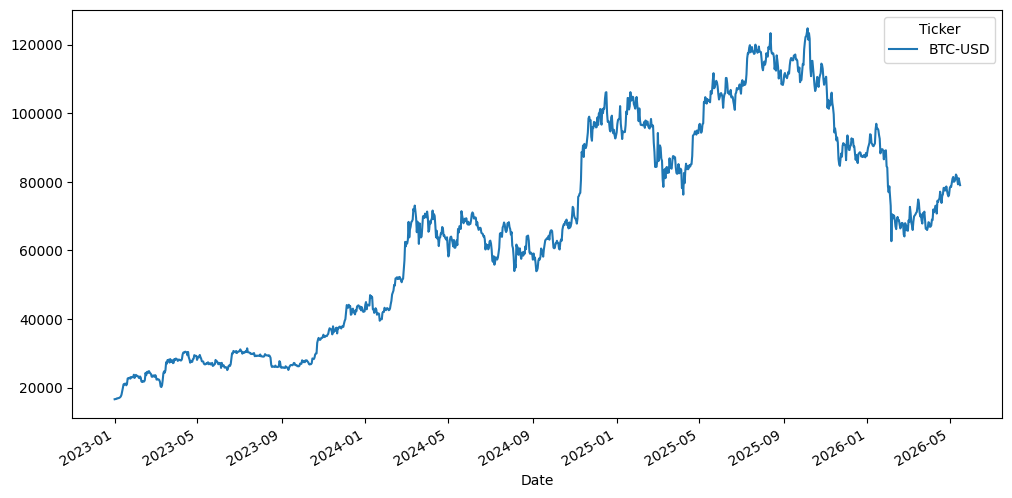

In [69]:
btc["Close"].plot(figsize=(12,6))

<Axes: title={'center': 'Bitcoin Closing Price'}, xlabel='Date'>

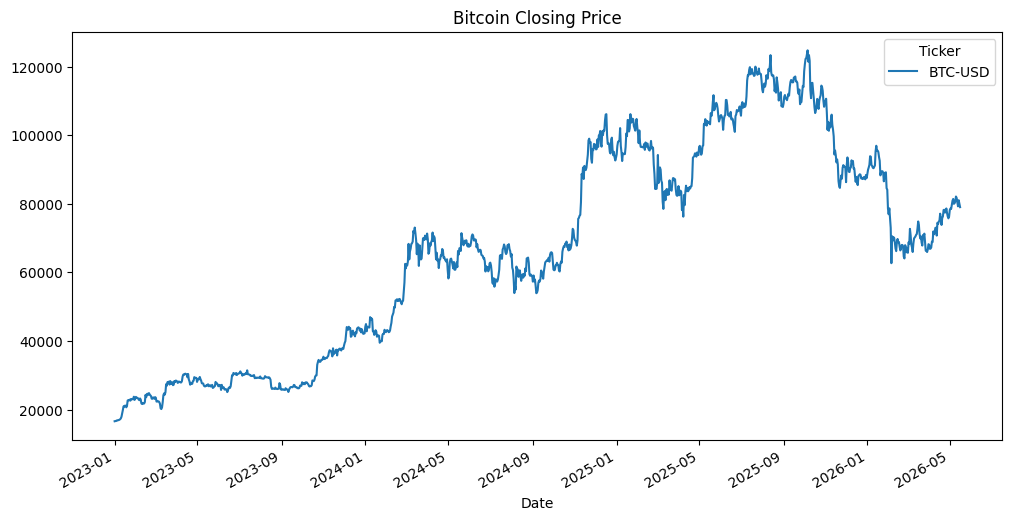

In [70]:
btc["Close"].plot(
    figsize=(12,6),
    title="Bitcoin Closing Price"
)

In [71]:
btc.to_csv("../data/btc_raw.csv")

In [72]:
btc_clean = btc.copy()
btc_clean.columns = btc_clean.columns.get_level_values(0)
btc_clean.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [73]:
btc_clean.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566


In [74]:
btc_clean["Daily Return"] = btc_clean["Close"].pct_change()
btc_clean.head()

Price,Close,High,Low,Open,Volume,Daily Return
Date,,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700,NaN
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227,0.003813
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207,-0.000516
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322,0.010994
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566,-0.001572


<Axes: title={'center': 'Bitcoin Daily Returns'}, xlabel='Date'>

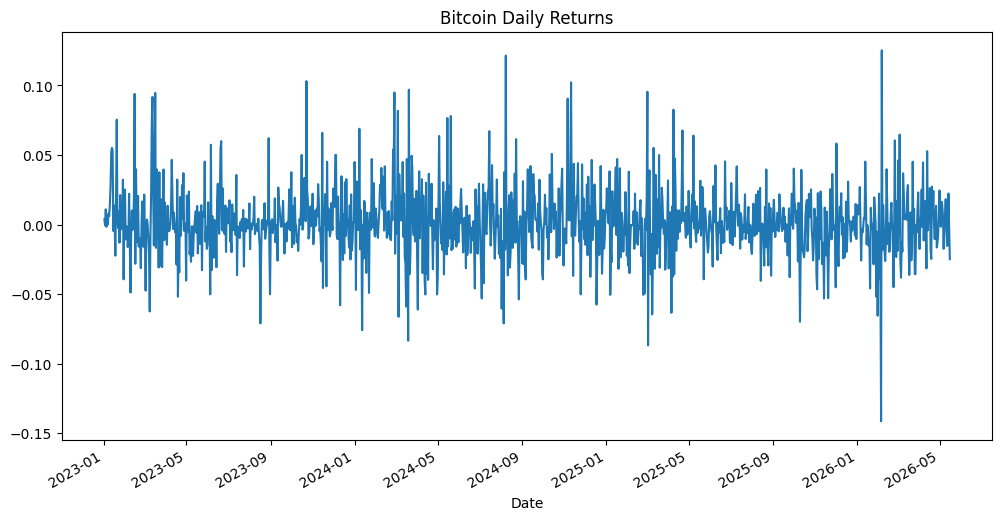

In [75]:
btc_clean["Daily Return"].plot(
    figsize=(12,6),
    title="Bitcoin Daily Returns"
)

In [76]:
btc_clean["Daily Return"].std()

np.float64(0.024813193910123613)

In [77]:
btc_clean["Daily Return"].max()

np.float64(0.1252476912623226)

In [78]:
btc_clean["Daily Return"].min()

np.float64(-0.14129892381358544)

In [79]:
btc_clean.to_csv("../data/btc_clean.csv")

In [80]:
btc_clean["MA_7"] = btc_clean["Close"].rolling(window=7).mean()

In [81]:
btc_clean["MA_30"] = btc_clean["Close"].rolling(window=30).mean()

In [82]:
btc_clean.head(35)

Price,Close,High,Low,Open,Volume,Daily Return,MA_7,MA_30
Date,,,,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700,NaN,NaN,NaN
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227,0.003813,NaN,NaN
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207,-0.000516,NaN,NaN
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322,0.010994,NaN,NaN
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566,-0.001572,NaN,NaN
2023-01-06,16951.968750,16991.994141,16716.421875,16836.472656,14413662913,0.006844,NaN,NaN
2023-01-07,16955.078125,16975.017578,16914.191406,16952.117188,7714767174,0.000183,16800.061384,NaN
2023-01-08,17091.144531,17091.144531,16924.050781,16954.146484,9768827914,0.008025,16866.642020,NaN
2023-01-09,17196.554688,17389.957031,17093.992188,17093.992188,18624736866,0.006168,16939.225446,NaN


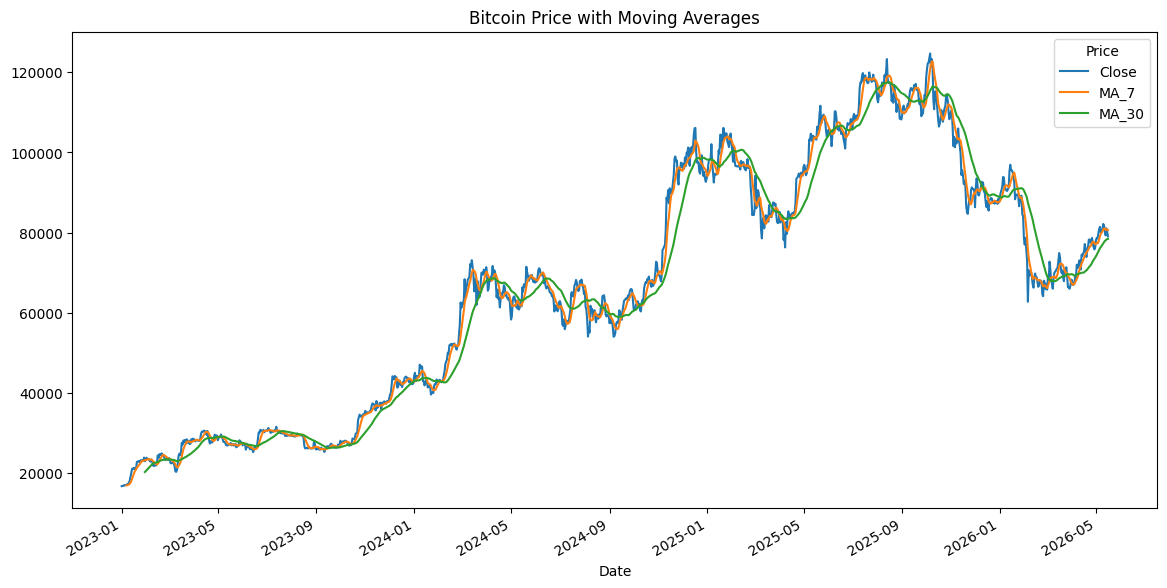

In [123]:
ax = btc_clean[["Close", "MA_7", "MA_30"]].plot(
    figsize=(14,7),
    title="Bitcoin Price with Moving Averages"
)

fig = ax.get_figure()
fig.savefig("../images/moving_average_chart.png", bbox_inches="tight")

In [124]:
btc_clean["Signal"] = 0
btc_clean.loc[btc_clean["MA_7"] > btc_clean["MA_30"], "Signal"] = 1
btc_clean.loc[btc_clean["MA_7"] < btc_clean["MA_30"], "Signal"] = -1

In [125]:
btc_clean[["Close", "MA_7", "MA_30", "Signal"]].tail(20)

Price,Close,MA_7,MA_30,Signal
Date,,,,
2026-04-26,78657.539062,77488.888393,72453.452604,1
2026-04-27,77366.625000,77702.331473,72821.683594,1
2026-04-28,76350.671875,77702.031250,73168.208594,1
2026-04-29,75776.132812,77355.321429,73471.031510,1
2026-04-30,76304.320312,77074.659598,73740.065104,1
2026-05-01,78179.000000,77178.043527,74076.746615,1
2026-05-02,78657.250000,77327.362723,74469.035937,1
2026-05-03,78538.226562,77310.318080,74855.940104,1
2026-05-04,79827.906250,77661.929688,75273.853125,1


In [126]:
btc_clean["Signal"].value_counts()

Signal
 1    664
-1    538
 0     29
Name: count, dtype: int64

In [127]:
btc_clean.to_csv("../data/btc_analysis_enriched.csv")

In [128]:
btc_clean["Cumulative Return"] = (
    1 + btc_clean["Daily Return"]
).cumprod()

<Axes: title={'center': 'Bitcoin Cumulative Returns'}, xlabel='Date'>

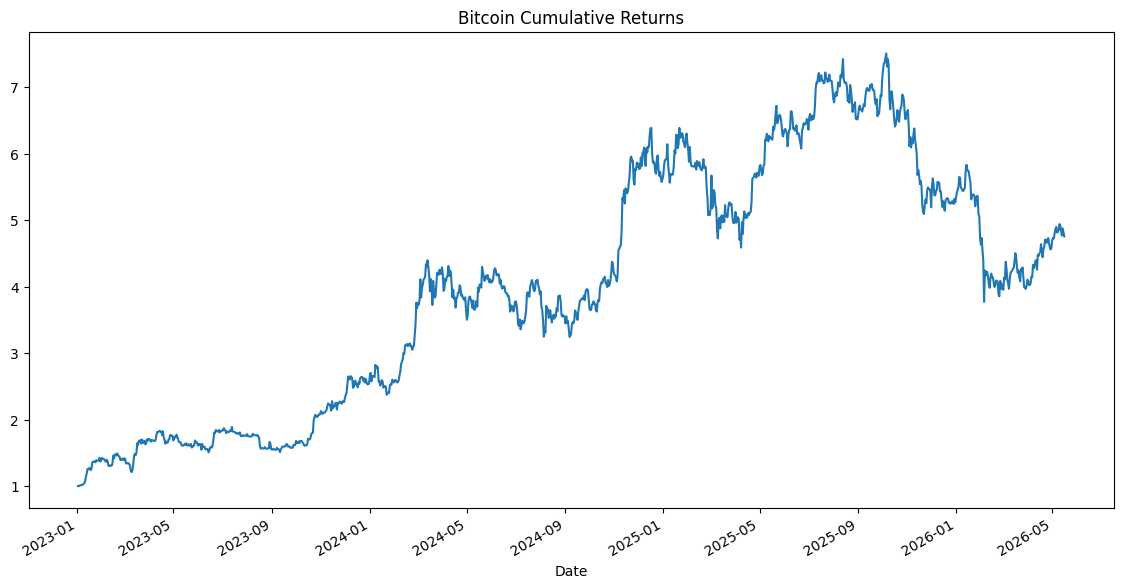

In [129]:
btc_clean["Cumulative Return"].plot(
    figsize=(14,7),
    title="Bitcoin Cumulative Returns"
)

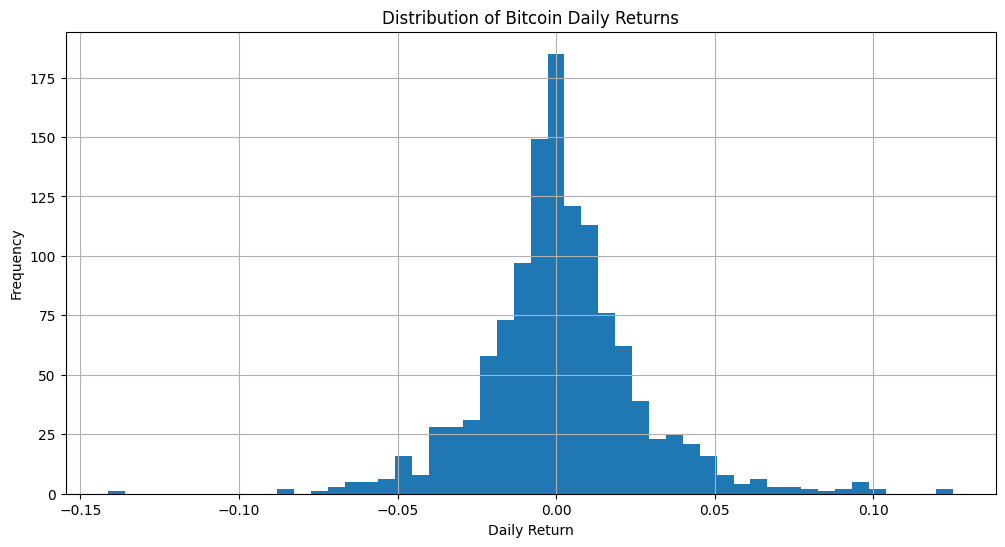

In [130]:
ax = btc_clean["Daily Return"].hist(
    bins=50,
    figsize=(12,6)
)

plt.title("Distribution of Bitcoin Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

fig = ax.get_figure()
fig.savefig("../images/return_distribution.png", bbox_inches="tight")

In [131]:
rolling_max = btc_clean["Close"].cummax()

drawdown = (
    btc_clean["Close"] - rolling_max
) / rolling_max

drawdown.min()

np.float64(-0.497388172985468)

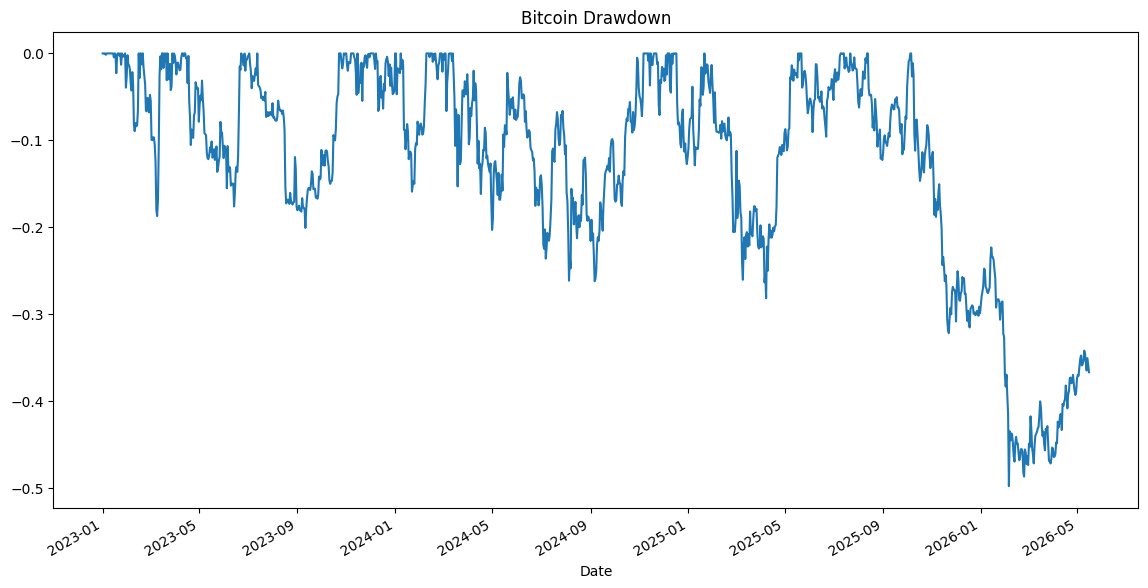

In [134]:
ax = drawdown.plot(
    figsize=(14,7),
    title="Bitcoin Drawdown"
)

fig = ax.get_figure()
fig.savefig("../images/drawdown_chart.png", bbox_inches="tight")

# Bitcoin Market Analysis

This project analyzes Bitcoin historical market data using Python and pandas.

Key analysis performed:
- Data cleaning
- Daily return calculations
- Volatility analysis
- Moving averages
- Trend signal generation
- Cumulative return analysis
- Drawdown analysis

The goal of this project is to explore foundational financial data analysis workflows and visualize Bitcoin market behavior over time.

# Key Findings

- Bitcoin exhibited high daily volatility compared to traditional financial assets.
- The 7-day moving average reacted significantly faster to price movements than the 30-day moving average.
- Bitcoin experienced several large drawdown periods, highlighting substantial downside risk.
- Despite volatility, the cumulative return trend remained positive over the analyzed period.

In [135]:
btc_clean.to_csv("../data/btc_final_analysis.csv")